# Tema 2
## Descrierea temei

Descrierea problemei și a setului de date se gasesc in `data/sign-mnist-readme.txt`. Setul de date este in fisierele `/data/sign-mnist_train.csv` și `/data/sign-mnist_train.csv`. Se va aplica model de regresie logistică pentru predicția etichetei clasei vestimentare din care face parte fiecare imagine (prima coloana din setul de date), folosind ca intrari valorile din celelalte coloane. 

Implementarea se va face folosind functii de NumPy. Se va folosi calcul vectorizat, pe cat posibil. 

Predarea temei se va face în data **19 noiembrie, ora 23**.

Cerinte si precizări:
1. Studenții se pot consulta intre ei, dar rezolvările vor fi individuale. Necunoașterea codului prezentat înseamnă nota 1 pentru tema curentă.

2. Să se faca adnotări de tipuri pentru variabilele folosite, parametrii de intrare ai funcțiilor și tipurile de retur. Neîndeplinirea acestei cerinte duce la **înjumatatirea notei**.

In [1]:
!uv add seaborn
!uv add tableprint
!uv add prettytable

Resolved 122 packages in 2ms
Audited 118 packages in 753ms
Resolved 122 packages in 2ms
Audited 118 packages in 17ms
Resolved 122 packages in 2ms
Audited 118 packages in 16ms


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Union
import seaborn as sns
from PIL import Image
import tableprint as tab

plt.rc('font', **{'size' : 18})

# Procesarea datelor de intrare

In [3]:
path_train: str = './data/sign_mnist_train.csv'
path_test: str = './data/sign_mnist_test.csv'


train_data: pd.DataFrame = pd.read_csv(path_train)
test_data: pd.DataFrame = pd.read_csv(path_test)

assert(train_data.shape) == (27455, 785),f'Fisierul nu a fost citit corect: s-a citit un continut de forma {train_data.shape}'
assert(test_data.shape) == (7172, 785),f'Fisierul nu a fost citit corect: s-a citit un continut de forma {test_data.shape}'


#primele 5 linii din setul de antrenare
train_data.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Numar de clase: 24


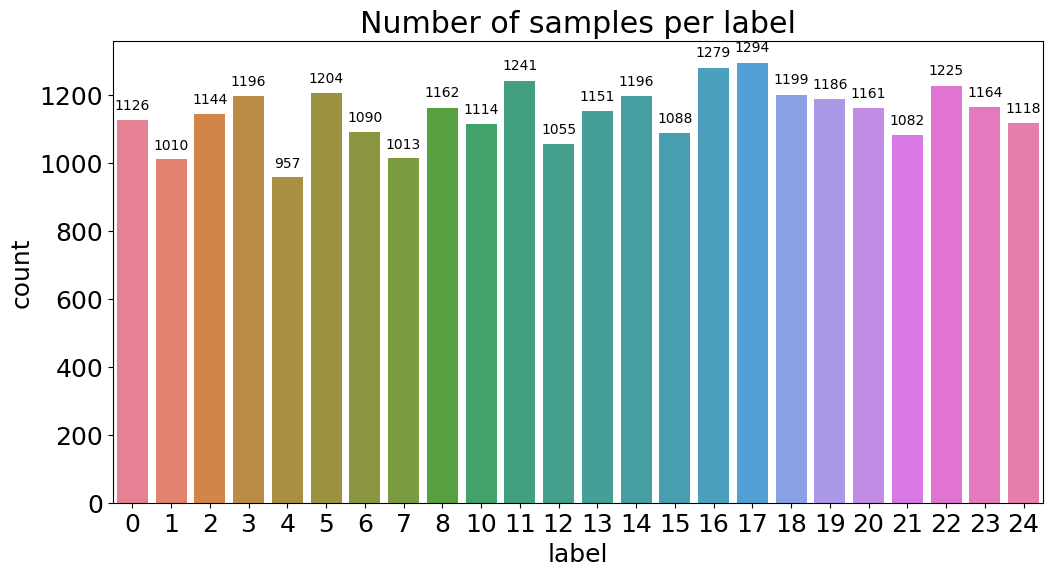

In [4]:
num_classes : int = train_data['label'].nunique() 
print(f'Numar de clase: {num_classes}')
palette : list = sns.color_palette('husl', num_classes)

plt.figure(figsize=(12,6))
# num_classes = len(top_classes)
palette : list = sns.color_palette('husl', num_classes)

ax : matplotlib.axes._subplots.AxesSubplot = sns.countplot(x='label', data=train_data, hue='label', palette=palette, dodge=False, legend=False)
plt.title('Number of samples per label')

# Add labels on top of each bar
for p in ax.patches:
    height : float = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.02*height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.show()

In [5]:
# train_set si test_set sunt matrice care contin pe prima coloana clasa (o cifra de la 0 la 9),
#  iar imaginea este pastrata incepand de pe coloana 1 pana la terminare.
# Decupati in train_x doar imaginile iar in train_y doar clasa,
#  si faceti acelasi lucru si pentru test_x si test_y

train_x : np.ndarray = train_data.iloc[:, 1:].values / 255.0 
train_y : np.ndarray = train_data.iloc[:, 0].values
test_x : np.ndarray = test_data.iloc[:, 1:].values / 255.0
test_y : np.ndarray = test_data.iloc[:, 0].values

# assert(train_data.shape) == (27455, 785),f'Fisierul nu a fost citit corect: s-a citit un continut de forma {train_data.shape}'
# assert(test_data.shape) == (7172, 785),f'Fisierul nu a fost citit corect: s-a citit un continut de forma {test_data.shape}'

assert train_x.shape == (27455, 784)
assert train_y.shape == (27455,)
assert test_x.shape == (7172, 784)
assert test_y.shape == (7172,)

Să vizualizăm setul de date. Vom reprezenta primele 16 linii din setul de antrenare:

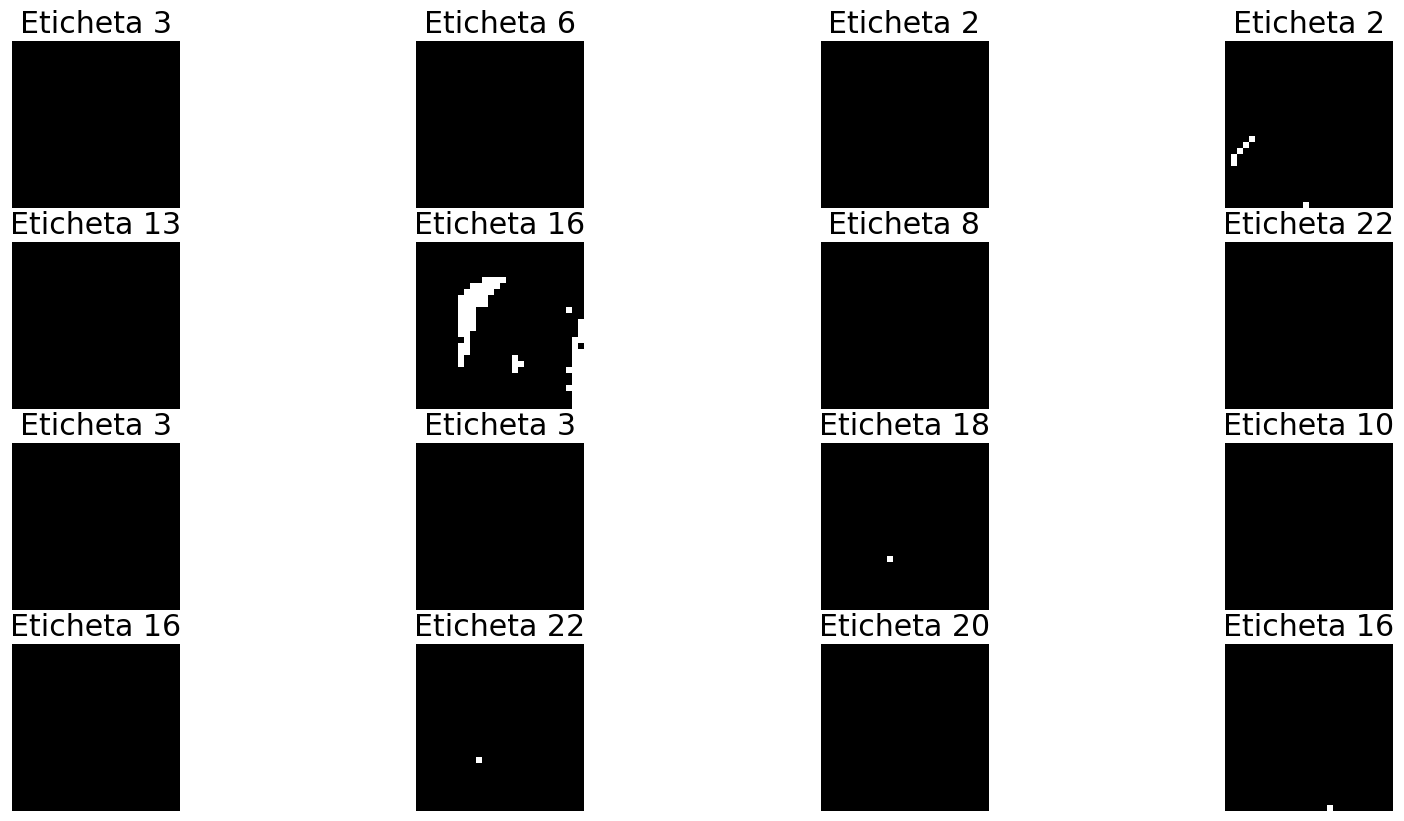

In [6]:
def show_samples(x_set : np.ndarray, y_set : np.ndarray) -> None:
    size : int = x_set.shape[0]

    fig : matplotlib.figure.Figure
    ax : nd.ndarray
    fig, ax = plt.subplots(size // 4, 4, figsize=(20, 10))
    for k in range(size):
        row, col = k // 4, k % 4
        
        # Make those columns into a array of 8-bits pixels
        # The pixel intensity values are integers from 0 to 255
        pixels : np.ndarray = np.array(x_set[k], dtype='uint8')    
        
        # Reshape the array into 28 x 28 array (2-dimensional array)
        n = int(np.sqrt(len(pixels)))
        assert n**2 == len(pixels)
        pixels = pixels.reshape(n, n)
        ax[row, col].imshow(pixels, cmap='gray')
        ax[row, col].set_title('Eticheta {label}'.format(label=y_set[k]))
        ax[row, col].axis('off')

    plt.show()
    
show_samples(train_x[:16, :], train_y[:16])

Să decodificăm etichetele imaginilor:


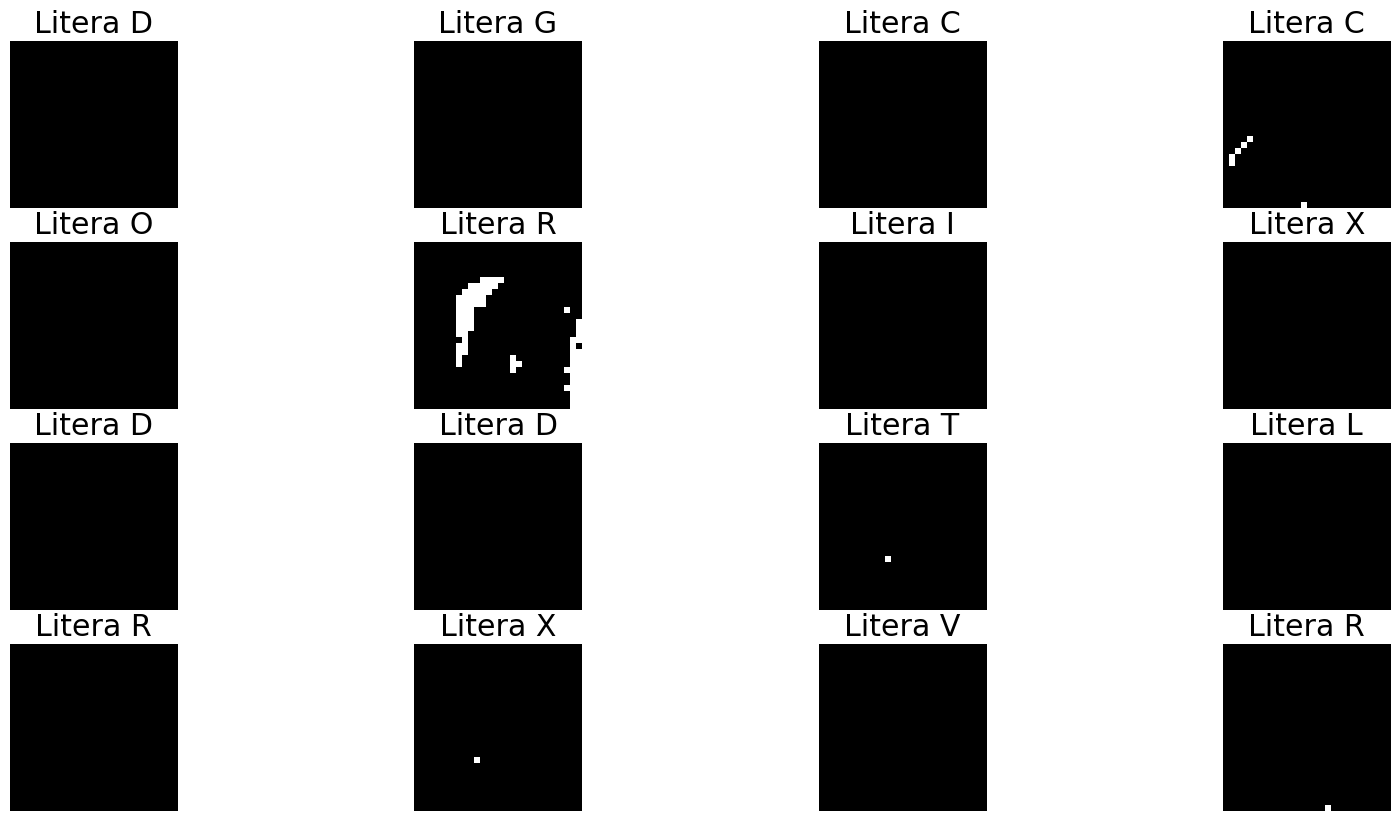

In [7]:
labels_map: dict[int,str] = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',10:'K',
             11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',
             20:'U',21:'V',22:'W',23:'X',24:'Y'}

# # Filter images with the chosen label
# filtered_images = train_df[train_df['label'] == target_label]

# # Display the first image of that label
# sample = filtered_images.iloc[0, 1:].values.reshape(28,28)
# plt.imshow(sample, cmap='gray')
# plt.title(f"Label: {target_label} → {label_map[target_label]}")
# plt.show()

classes : list[str] = list(labels_map.values())

# classes[y[i,0]]
def show_samples(x_set : np.ndarray, y_set : np.ndarray) -> None:
    size : int = x_set.shape[0]

    fig : matplotlib.figure.Figure
    ax : np.ndarray
    fig, ax = plt.subplots(size // 4, 4, figsize=(20, 10))
    for k in range(size):
        row, col = k // 4, k % 4
        
        # Make those columns into a array of 8-bits pixels
        # The pixel intensity values are integers from 0 to 255
        pixels : nd.ndarray = np.array(x_set[k], dtype='uint8')    
        
        # Reshape the array into 28 x 28 array (2-dimensional array)
        n = int(np.sqrt(len(pixels)))
        assert n**2 == len(pixels)
        pixels = pixels.reshape(n, n)
        ax[row, col].imshow(pixels, cmap='gray')
        ax[row, col].set_title('Litera {label}'.format(label=classes[y_set[k]]))
        ax[row, col].axis('off')

    plt.show()
    
show_samples(train_x[:16, :], train_y[:16])


In [8]:
print("Clasa   Numărul imaginilor \n ", pd.Series(train_y).value_counts())
print("Clasa 9 lipsește! \n Pentru identificarea literei J și Z sunt necesare mișcari ale mâinii, nu doar imagini statice.\nRenumerotăm etichetele:")
 # Relabel the top_classes_train to 0-9 
print(len(classes))
print("Labels map for top classes:")
new_labels : dict[int,int] = {cls: i for i, cls in enumerate(list(labels_map.keys()))}
print(new_labels)
train_y : np.ndarray = np.array([new_labels[label.item()] for label in train_y])
print("Relabeled train labels shape:", train_y.shape)
# Relabel the top_classes_test to 0-9
test_y : np.ndarray = np.array([new_labels[label] for label in test_y])
print("Relabeled test labels shape:", test_y.shape)

Clasa   Numărul imaginilor 
  17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
14    1196
3     1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64
Clasa 9 lipsește! 
 Pentru identificarea literei J și Z sunt necesare mișcari ale mâinii, nu doar imagini statice.
Renumerotăm etichetele:
24
Labels map for top classes:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}
Relabeled train labels shape: (27455,)
Relabeled test labels shape: (7172,)


## Regresia Multinomială

Functia de mai jos adauga o coloana de 1 la o matrice, pentru a putea reprezenta si ponderea pentru termenul liber (la fel cum am procedat în cazul regresiei liniare).

In [9]:
def augment_matrix(x: np.ndarray) -> np.ndarray:
    """
    Returns a matrix with first column filled with 1 and the other columns being x's columns.
    """
    column_ones : np.ndarray = np.ones((x.shape[0],1))
    result : np.ndarray = np.hstack((column_ones,x))
    return result

train_x_bin_ext : np.ndarray = augment_matrix(train_x)
test_x_bin_ext : np.ndarray = augment_matrix(test_x)

assert train_x_bin_ext.shape == (27455, 785)
assert test_x_bin_ext.shape == (7172, 785)
assert np.all(train_x_bin_ext[:, 0] == 1)
assert np.all(test_x_bin_ext[:, 0] == 1)


Funcția următoare trebuie să preia o matrice si să faca scalarea la intervalul [0, 1] a fiecărei coloane (trăsături/feature) (similar scalării cu valorile de minim și maxim din regresia liniră).
Fiind valori de pixeli, valoarea maximă este 255. Prin urmare, normalizarea va presupune doar împărțirea Feature-urilor la valoarea maximă, 255.

In [10]:

def normalize(x: np.ndarray) -> np.ndarray:
    """
    Normalization means division by 255.
    
    Args:
        x: feature matrix, shape m * n. It will not be changed by this code.
    
    Returns:
        matrix with scaled values between 0 and 1, of same shape
    """
    return x/255.0

## testarea funcției
train_x_ext : np.ndarray = augment_matrix(normalize(train_x))
test_x_ext : np.ndarray = augment_matrix(normalize(test_x))

assert train_x_ext.shape == (27455, 785)
assert test_x_ext.shape == (7172, 785)
assert np.all(train_x_ext[:, 0] == 1)
assert np.all(test_x_ext[:, 0] == 1)


assert np.all(train_x_ext <= 1)
assert np.all(test_x_ext <= 1)
assert np.all(train_x_ext >= 0)
assert np.all(test_x_ext >= 0)

Pentru început, pentru întreg setul de antrenare:
* vom normaliza matricea de Feature-uri
* vom adăuga coloana de 1-uri, corespunzătoare termenului liber.

In [11]:
# classes
k : int = num_classes
# k=len(selected_classes)
print("Number of selected classes:", k)



# Adaugam la features coloana de 1-uri
train_x_all_ext : np.ndarray = augment_matrix(normalize(train_x))
test_x_all_ext : np.ndarray = augment_matrix(normalize(test_x))

assert train_x_all_ext.shape == (27455, 785)
assert test_x_all_ext.shape == (7172, 785)
assert np.all(train_x_all_ext[:, 0] == 1)
assert np.all(test_x_all_ext[:, 0] == 1)
assert np.all(train_x_all_ext <= 1)
assert np.all(test_x_all_ext <= 1)
assert np.all(train_x_all_ext >= 0)
assert np.all(test_x_all_ext >= 0)

Number of selected classes: 24


În continuare, vom realiza codificarea 'one-hot encoding', prin care vom converti un număr intreg la un array binar,
care are 1 doar pe o anumită poziție specificată.
Concret, în cazul nostru, fiecare clasă va fi codificată într-un vector k-dimensional (k=10=numărul claselor), format din zero-uri și valoarea 1 pe poziția aferentă clasei.

De exemplu:
 * 4 devine `[0 0 0 0 1 0 0 0 0 0]`
 * 0 devine `[1 0 0 0 0 0 0 0 0 0]`

In [12]:

def one_hot(val: int, classes: int) -> np.ndarray:
    """
    Realizeaza 'one-hot encoding', conversia unui intreg la un array binar,
    care are 1 doar pe pozitia specificata de val
    
    Args:
        val: clasa ce trebuie encodata, un intreg intre {0, 1, ... K-1}
        classes: numarul de clase K
        
    Returns:
        un array de zerouri de forma (1, classes), unde doar pe pozitia val avem o valoare 1
    """
    assert 0 <= val < classes,f'Valoarea {val} nu este intre 0 si {classes}'
   
    result : np.ndarray = np.zeros((1,classes))
    result[0,val]=1
    
    assert result.shape == (1, classes)
    return result
    
## for all 25 classes
assert np.all(one_hot(7, k) == np.array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]))
assert np.all(one_hot(3, k) == np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]))
train_y_all : np.ndarray = np.concatenate([one_hot(int(i), k) for i in train_y])
test_y_all : np.ndarray = np.concatenate([one_hot(int(i), k) for i in test_y])
assert train_y_all.shape == (27455, 24),f'Forma train_y_all: {train_y_all.shape}'
assert test_y_all.shape == (7172, 24),f'forma test_y_all: {test_y_all.shape}'
assert np.all((train_y_all != 0) == (train_y_all == 1))

Când calculăm produsul între matricea $X$, de dimensiune $(m, n)$, şi $\theta$, de dimensiune $(n, k)$,obținem rezultatul $X \theta$, de dimensiune $(m, k)$, unde:
* m = numărul de samples (imagini)
* n  =numărul de feature-uri
* k= numărul de clase

Funcţia $softmax()$ va avea aceleaşi dimensiuni $(m, k)$ şi trebuie să dea pe fiecare coloană suma $1$. Se poate scrie compact calculul ei astfel:

$$softmax(X, \theta) = \frac{e^{X \theta}}{e^{X \theta} \cdot \mathbb{1}_k}$$

Termenul de la numitor, $e^{X \theta} \cdot \mathbb{1}_k$, nu mai este o matrice, ci un vector de dimensiunea $(m, 1)$ (practic se realizează suma pe fiecare linie). Pentru realizarea împărţirii se realizează operaţia de broadcast.

In [13]:
# Vom verifica dimensiunile rezultate din  X@ Theta
m : int
n : int
m, n = train_x_all_ext.shape
np.random.seed(11)
theta : np.ndarray = np.random.randn(n, k)
assert (train_x_all_ext @ theta).shape == (m, k)

In [14]:
def softmax(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """"
    Calculul functie softmax
    
    Args:
        x: feature-urile, dimensiune m x n
        theta: parametrii, de dimensiune n x k
        
    Returns:
        produsul lor de dimensiune m x k
    """
    assert x.shape[1] == theta.shape[0]
    k : int = theta.shape[1]
    e_x_theta : np.ndarray = np.exp(x @ theta - np.max(x @ theta, axis=1, keepdims=True))
    e_x_theta_1 : np.ndarray = np.sum(e_x_theta,axis=1,keepdims=True)
    return e_x_theta / e_x_theta_1

m : int
n : int
m, n = train_x_all_ext.shape
np.random.seed(11)
theta : np.ndarray = np.random.randn(n, k)
smax : np.ndarray = softmax(train_x_all_ext, theta)
assert smax.shape == (m, k)
assert np.all((smax.sum(axis=1) - 1) < 1e-12)

Funcţia de cost ce include regularizarea poate fi scrisă mai compact astfel (a se remarca indicele de sumare $i$ plecand de la 1):

$$J(\theta, \lambda) = -\frac{1}{m} \mathbb{1}_m^T \left\{ Y \odot \log[softmax(X \theta)] \mathbb{1}_k \right\} + \frac{\lambda}{2} \sum_{i=1}^{n-1}\sum_{j=0}^{k-1} \theta_{i,j}^2 = -\frac{1}{m} \mathbb{1}_m^T \left\{ Y \odot \log[softmax(X \theta)] \mathbb{1}_k \right\} + \frac{\lambda}{2} \|\Theta[1:, :]\|_F^2$$

unde pentru o matrice $A$ de tip $m\times n$, $\| A \|_F$ e norma Forbenius: $$\| A \|_F = \sqrt{\sum\limits_{i=0}^{m-1}\sum\limits_{j=0}^{n-1} |a_{ij}|^2}$$

In [15]:

def cost(x : np.ndarray, y : np.ndarray, theta : np.ndarray, lmbda : float) -> np.ndarray:
    """
    Costul include regularizarea
    
    Args:
        x: feature-urile, dimensiune m x n
        y: clasele, de dimensiune m x k
        theta: parametrii, de dimensiune n x k
        lmbda: parametrul de regularizare, scalar
        
    Returns:
        costul, ca scalar

    """
    m : int = x.shape[0]
    one_m : np.ndarray = np.ones((m,1))
    one_k : np.ndarray = np.ones((k,1))
    y_hat : np.ndarray = softmax(x,theta)
    term1 : np.ndarray = (-1/m) * (one_m.T @ (y * np.log(y_hat) @ one_k))
    
    term2 : np.ndarray = (lmbda/2) * np.sum(theta[1:,:]**2)
    return (term1 + term2).flatten()

m : int
n : int
m, n = train_x_all_ext.shape
np.random.seed(11)
theta : np.ndarray = np.random.randn(n, k)
assert (cost(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2) - 1985.31901041) < 1e-6, f'Costul calculat este {cost(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2)}'

Gradientul se calculează astfel:

$$\nabla_{\theta}J = - \frac{1}{m} X^T \left[Y - softmax(X \theta) \right] + \lambda \left[ \mathbb{0}_n, \theta_{1 \dots k-1} \right]$$

unde matricea $\left[ \mathbb{0}_n, \theta_{1 \dots k-1} \right]$ are tot dimensiunea (n, k), ca şi $\theta$, doar că prima linie este zero.

In [16]:

def deltas(x : np.ndarray, y : np.ndarray, theta: np.ndarray, lmbda : float) -> np.ndarray:
    """
    Calculeaza gradientul

    Args:
        x: feature-urile, dimensiune m x n
        y: clasele, de dimensiune m x k
        theta: parametrii, de dimensiune n x k
        lmbda: parametrul de regularizare, scalar
        
    Returns:
        matricea gradientilor, de dimensiunea lui theta (n x k)
    """
    m : int = x.shape[0]
    y_hat : np.ndarray = softmax(x, theta)
    theta_0 : np.ndarray = theta.copy()
    theta_0[0, :] = 0
    return (-1/m) * (x.T @ (y-y_hat)) + lmbda * theta_0

m : int
n : int
m, n = train_x_all_ext.shape
np.random.seed(11)
theta : np.ndarray = np.random.randn(n, k)
grad : np.ndarray = deltas(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2)

assert grad.shape == (n, k)

Să calculăm acuratețea modelului:

In [17]:
def calculate_accurracy(set_x : np.ndarray, set_y : np.ndarray, theta : np.ndarray) -> float:
    y_hat : np.ndarray = softmax(set_x,theta)
    max_y_hat : np.ndarray = np.argmax(y_hat, axis=1)
    max_y_all : np.ndarray = np.argmax(set_y, axis=1)
    return (max_y_hat == max_y_all).sum() / set_x.shape[0] * 100.0

Să antrenăm modelul de regresie multinomială.


In [18]:
# numarul de clase
k : int = num_classes
# k=len(selected_classes)
lmbda : float
alpha : float
lmbda, alpha = 0.05 , 0.1
m : int
n : int
m, n = train_x_all_ext.shape
np.random.seed(11)
theta : np.ndarray = np.random.randn(n, k)

epochs : int = 500
values : list[np.ndarray] = []
accurracies : list[float] = []
for i in range(epochs):
    theta -= alpha * deltas(train_x_all_ext, train_y_all, theta, lmbda)
    if (i % 10 == 0):
        values.append(cost(train_x_all_ext, train_y_all, theta, lmbda))
        accurracies.append(calculate_accurracy(test_x_all_ext, test_y_all, theta))
        print("epoch: ", i, "cost: ", values[-1], "accuracy: ", accurracies[-1])
        lmbda *= 0.9
    
print("last costs: %g" % values[-1][0])

epoch:  0 cost:  [467.69534854] accuracy:  4.6151701059676515
epoch:  10 cost:  [385.22832519] accuracy:  4.6151701059676515
epoch:  20 cost:  [320.25678106] accuracy:  4.6151701059676515
epoch:  30 cost:  [268.48434918] accuracy:  4.6151701059676515
epoch:  40 cost:  [226.79641135] accuracy:  4.6151701059676515
epoch:  50 cost:  [192.90459066] accuracy:  4.601226993865031
epoch:  60 cost:  [165.10636613] accuracy:  4.517568321249303
epoch:  70 cost:  [142.12012704] accuracy:  4.378137200223089
epoch:  80 cost:  [122.97042264] accuracy:  4.196876742889013
epoch:  90 cost:  [106.90709239] accuracy:  3.904071388733965
epoch:  100 cost:  [93.34757564] accuracy:  3.4439486893474625
epoch:  110 cost:  [81.83528241] accuracy:  3.1790295593976574
epoch:  120 cost:  [72.0092277] accuracy:  3.248745119910764
epoch:  130 cost:  [63.58165451] accuracy:  3.332403792526492
epoch:  140 cost:  [56.32138432] accuracy:  2.9559397657557165
epoch:  150 cost:  [50.04131538] accuracy:  2.9141104294478524
e

Vom reprezenta grafic acuratețea și funcția de cost pentru modelul  nostru:

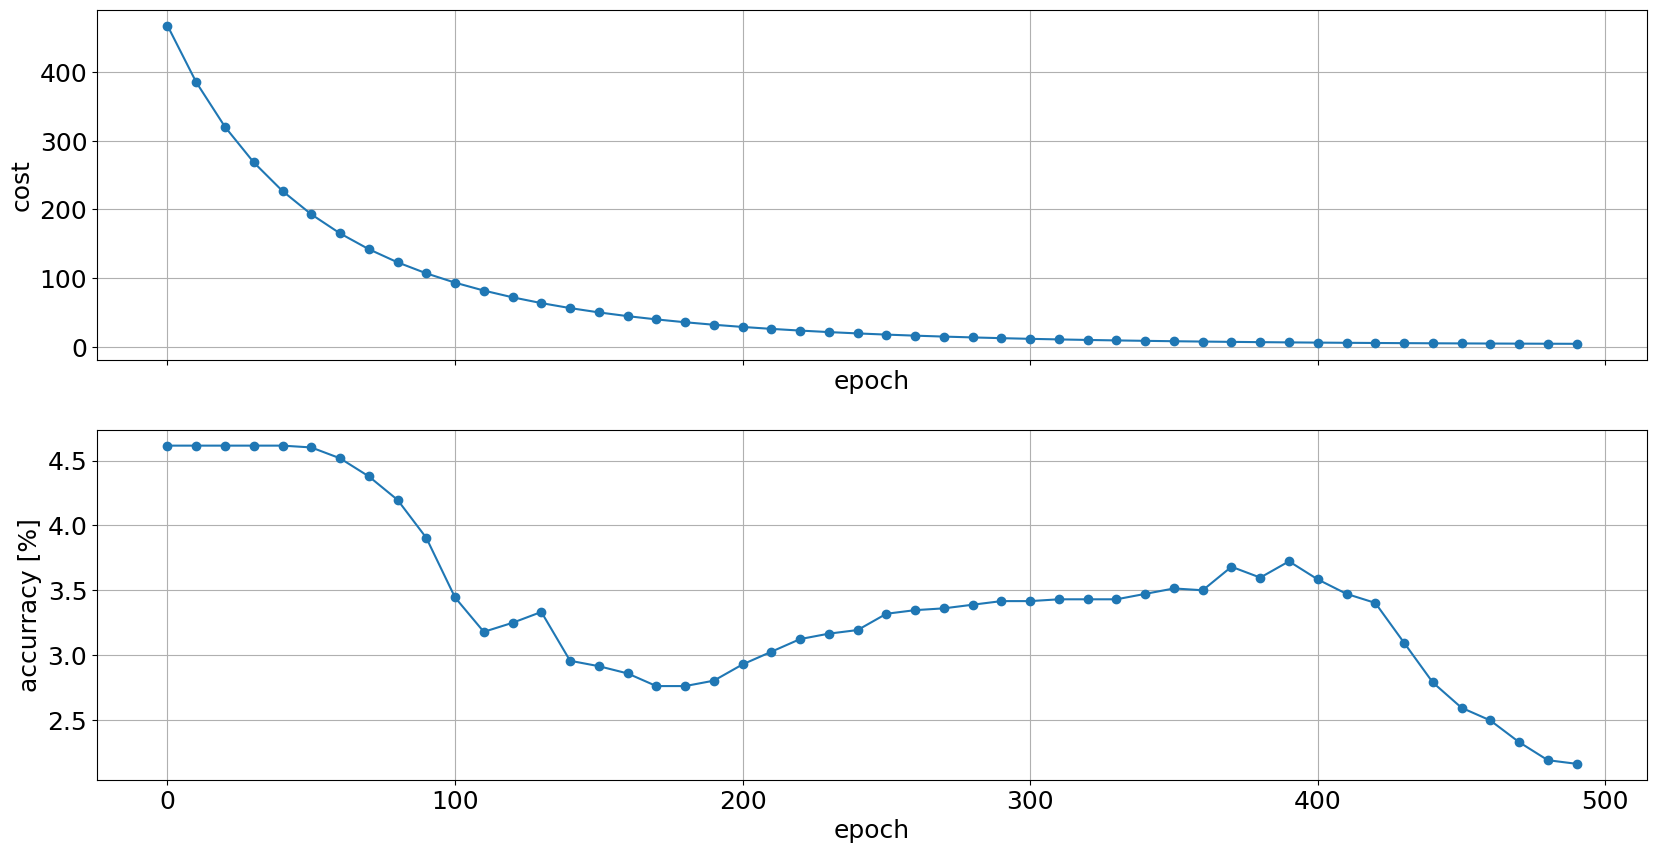

In [19]:
fig : matplotlib.figure.Figure
ax : np.ndarray
fig, ax = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
ax[0].plot([x * 10 for x in range(len(values))], values, 'o-')
ax[0].set_xlabel('epoch') ; ax[0].set_ylabel('cost')
ax[0].grid()
ax[1].plot([x * 10 for x in range(len(accurracies))], accurracies, 'o-')
ax[1].set_xlabel('epoch') ; ax[1].set_ylabel('accurracy [%]')
ax[1].grid()
plt.show()

## Testarea modelului de regresie multinomială

Să calculăm acuratețea pentru setul de test. Aceasta presupune să numărăm câte predicții se potrivesc cu realitatea și să exprimăm acest lucru procentual:

In [20]:
# Calculam acuratetea pentru setul de test
# Aceasta presupune sa numaram cate predictii se potrivesc cu realitatea si sa exprimam acest lucru procentual
y_hat_test : np.ndarray =softmax(test_x_all_ext,theta)
pred : np.ndarray = np.argmax(y_hat_test,axis=1)
actual : np.ndarray = np.argmax(test_y_all, axis=1)
equalities : int = np.sum(pred == actual)
print("Test accuracy: %2.2f%%" % ( equalities/test_y_all.shape[0]*100 ))



Test accuracy: 2.11%


### Matricea de confuzie 

In [21]:
from prettytable import PrettyTable

# Your existing code for conf_matrix calculation
pred : np.ndarray = np.argmax(y_hat_test, axis=1)
actual : np.ndarray = np.argmax(test_y_all,axis=1)

actual_oh : np.ndarray = np.zeros((actual.size, k))
pred_oh : np.ndarray = np.zeros((pred.size, k))

actual_oh[np.arange(actual.size), actual] = 1
pred_oh[np.arange(pred.size), pred] = 1

k_2 : int = int(k/2)

conf_matrix : np.ndarray = np.zeros((k, k), dtype=int)
for i in range(k):
    for j in range(k):
        conf_matrix[i,j] = np.sum(np.logical_and(actual_oh[:,i]==1, pred_oh[:,j]==1))

def print_split_confusion_matrix(conf_matrix : np.ndarray, k : int, k_2 : int) -> None:
    """Print confusion matrix split into two parts with PrettyTable"""
    
    # First half
    print("╔" + "═"*50 + "╗")
    print("║        FIRST HALF - CLASSES 0 to {:<2}         ║".format(k_2-1))
    print("╚" + "═"*50 + "╝")
    
    pt1 : PrettyTable = PrettyTable()
    pt1.field_names : list[str] = ['Act\nPred'] + [f'P{x}' for x in range(k)] + ['Total']
    for i in range(k_2):
        row : list[int | str] = [f'A{i}'] + [int(conf_matrix[i,j]) for j in range(k)] + [int(np.sum(conf_matrix[i,:]))]
        pt1.add_row(row)
    pt1.add_row(['Total'] + [int(np.sum(conf_matrix[:k_2, j])) for j in range(k)] + [int(np.sum(conf_matrix[:k_2, :]))])
    print(pt1)
    
    # Second half  
    print("\n╔" + "═"*50 + "╗")
    print("║        SECOND HALF - CLASSES {:<2} to {:<2}         ║".format(k_2, k-1))
    print("╚" + "═"*50 + "╝")
    
    pt2 : PrettyTable = PrettyTable()
    pt2.field_names : list[str] = ['Act\nPred'] + [f'P{x}' for x in range(k)] + ['Total']
    for i in range(k_2, k):
        row : list[int | str] = [f'A{i}'] + [int(conf_matrix[i,j]) for j in range(k)] + [int(np.sum(conf_matrix[i,:]))]
        pt2.add_row(row)
    pt2.add_row(['Total'] + [int(np.sum(conf_matrix[k_2:, j])) for j in range(k)] + [int(np.sum(conf_matrix[k_2:, :]))])
    print(pt2)

print_split_confusion_matrix(conf_matrix, k, k_2)

╔══════════════════════════════════════════════════╗
║        FIRST HALF - CLASSES 0 to 11         ║
╚══════════════════════════════════════════════════╝
+-------+----+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+------+-----+-----+-----+-----+-----+-----+-----+-------+
|    Act
Pred    | P0 | P1 | P2 | P3 | P4 | P5 | P6 | P7 | P8 | P9 | P10 | P11 | P12 | P13 | P14 | P15 | P16  | P17 | P18 | P19 | P20 | P21 | P22 | P23 | Total |
+-------+----+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+------+-----+-----+-----+-----+-----+-----+-----+-------+
|   A0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  |  0  |  0  |  0  |  0  |  0  |  0  | 312  |  19 |  0  |  0  |  0  |  0  |  0  |  0  |  331  |
|   A1  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  |  0  |  0  |  0  |  0  |  0  |  0  | 432  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  432  |
|   A2  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  | 0  |  0  |  0  | 

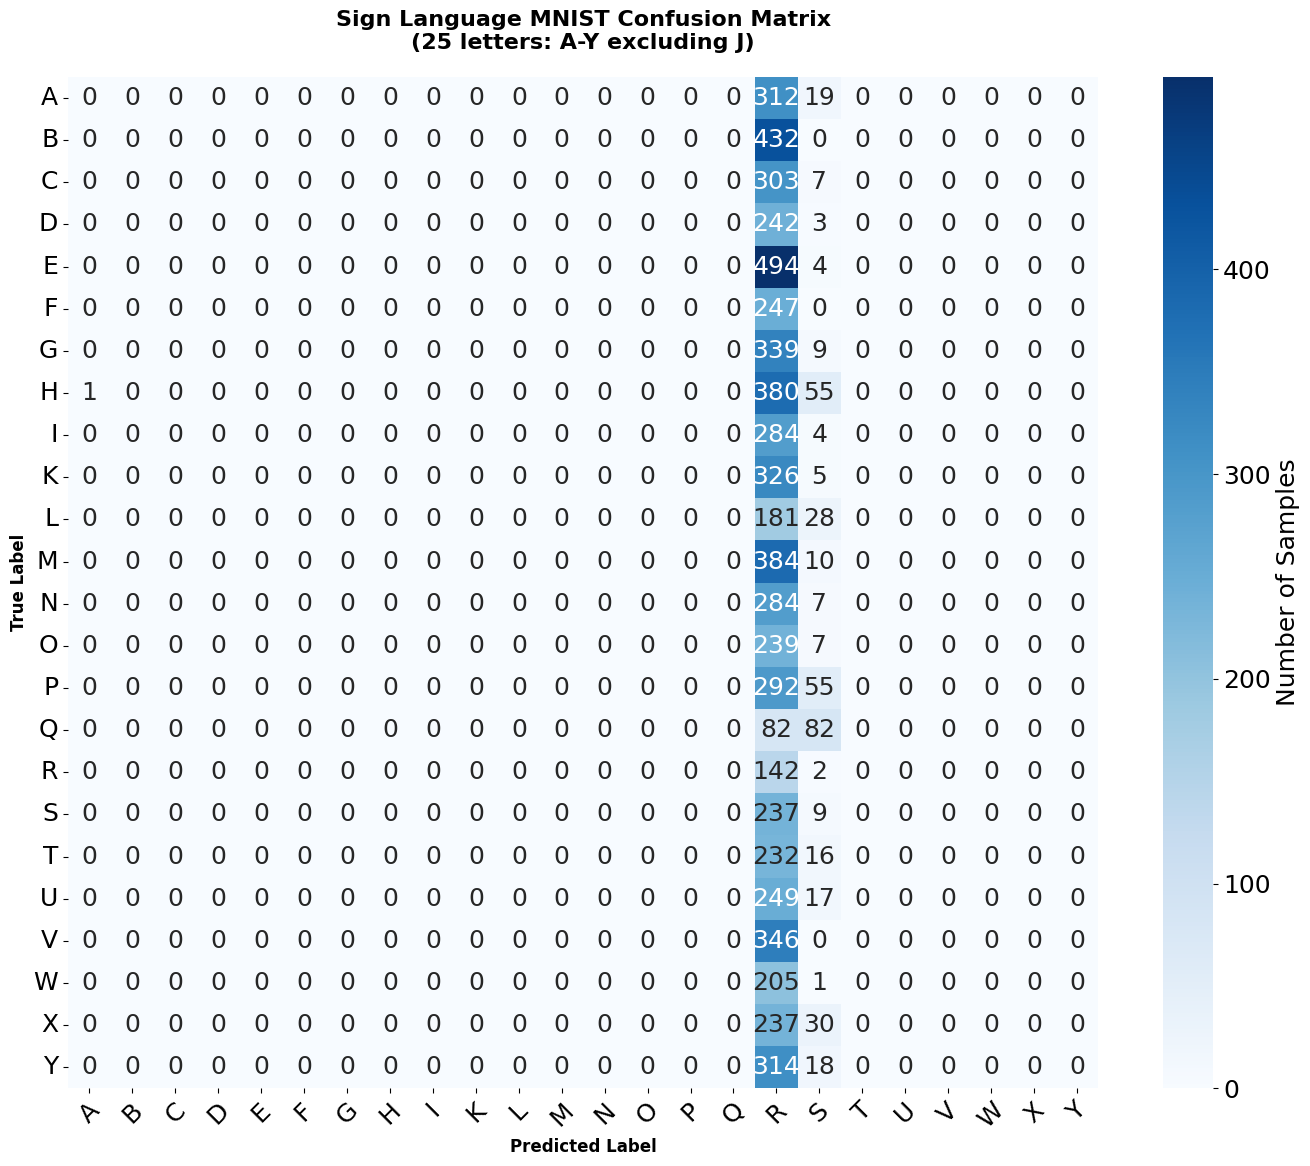

In [22]:
from sklearn.metrics import confusion_matrix
pred : np.ndarray = np.argmax(softmax(test_x_all_ext, theta), axis=1)
actual : np.ndarray = np.argmax(test_y_all, axis=1)
asl_letters : list[str] = list(labels_map.values())
cm : np.ndarray = confusion_matrix(actual, pred)
    
plt.figure(figsize=(14, 12))

sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=asl_letters,
            yticklabels=asl_letters,
            cbar_kws={'label': 'Number of Samples'})

plt.title('Sign Language MNIST Confusion Matrix\n(25 letters: A-Y excluding J)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()